# Prapemrosesan Teks dan Ekstraksi Fitur TF-IDF

Data teks hasil crawling tidak dapat langsung digunakan oleh algoritma karena masih berupa data mentah. Oleh karena itu, teks perlu diproses terlebih dahulu agar lebih bersih dan siap dikonversi menjadi data numerik menggunakan metode TF-IDF.

Tahapan yang dilakukan dalam prapemrosesan data adalah sebagai berikut:

1. **Cleansing dan Case Folding**  
   Membersihkan teks dari angka, tanda baca, simbol, dan karakter yang tidak diperlukan. Selanjutnya, seluruh teks diubah menjadi huruf kecil.

2. **Stopword Removal**  
   Menghapus kata-kata umum yang dianggap kurang memberikan informasi penting dalam proses analisis teks.

3. **Stemming**  
   Mengubah kata yang memiliki imbuhan ke bentuk kata dasarnya sehingga kata yang memiliki makna serupa dapat diperlakukan sebagai satu fitur.

4. **Ekstraksi TF-IDF**  
   Teks yang telah melalui tahap prapemrosesan kemudian direpresentasikan dalam bentuk angka menggunakan TF-IDF. Nilai tersebut menunjukkan tingkat kepentingan suatu kata pada setiap dokumen.

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# 1. Memuat Dataset
df = pd.read_csv('data_berita_sport_finance_saya.csv')
# Menggabungkan fitur judul dan isi untuk konteks yang lebih kaya
df['Teks Mentah'] = df['Judul Berita'] + " " + df['Isi Berita']

# 2. Inisialisasi NLP Tools
stop_words_id = set(stopwords.words('indonesian'))
stop_words_en = set(stopwords.words('english'))
stop_words_final = stop_words_id.union(stop_words_en)
# Tambahan daftar kata penghubung dan singkatan yang sering muncul di berita
custom_stopwords = {
    'dan','atau','yang','dengan','juga','karena','namun','sehingga','adalah','akan',
    'saat','pada','untuk','dari','oleh','dalam','dapat','kami','mereka','kita','saya',
    'ini','itu','tersebut','tsb','dll','dkk','spt','yg','dgn','dr','jr','sr','thn',
    'tdk','gak','nggak','ya','ia','mereka','terkait','berdasarkan','setelah','sebelum',
    'sambil','selain','sekitar','hingga','maupun','bisa','per','waktu','apakah','adanya'
}
stop_words_final = stop_words_final.union(custom_stopwords)
stemmer = StemmerFactory().create_stemmer()

def bersihkan_teks(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in stop_words_final and len(w) > 1]
    # Menerapkan stemming dan menghapus stopword
    processed_words = [stemmer.stem(w) for w in words]
    return ' '.join(processed_words)

print("Memproses pembersihan teks (estimasi waktu: 2-4 menit)...")
df['Teks Bersih'] = df['Teks Mentah'].apply(bersihkan_teks)
display(df[['Kategori', 'Teks Bersih']].head())

Memproses pembersihan teks (estimasi waktu: 2-4 menit)...


,Kategori,Teks Bersih
0,SPORT,asi games banjir landa nagoya menpora jepang p...
1,SPORT,timnas basket putra asi games tang laga latih ...
2,FINANCE,suahasil pegawai menteri uang kredibel menteri...
3,SPORT,asi games putri kw pede komposisi regu putri p...
4,SPORT,asi games tum pbti taekwondo kontribusi indone...


## Ekstraksi Fitur: TF-IDF (*Term Frequency - Inverse Document Frequency*)

Metode *Bag-of-Words* (BOW) digunakan untuk mengubah data teks menjadi bentuk numerik berdasarkan kemunculan kata. Namun, metode ini belum dapat menunjukkan tingkat kepentingan setiap kata. Selain itu, hasil representasinya dapat menghasilkan matriks yang memiliki banyak nilai nol (*sparsity*).

Untuk mendapatkan bobot kata yang lebih sesuai, digunakan metode **TF-IDF**. Metode ini mempertimbangkan frekuensi sebuah kata dalam suatu dokumen serta frekuensi kemunculan kata tersebut pada seluruh dokumen.

Rumus TF-IDF dapat dituliskan sebagai berikut:

$$
TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)
$$

Nilai IDF dihitung menggunakan rumus:

$$
IDF(t) = \log\left(\frac{N}{df(t)}\right)
$$

Keterangan:
- $t$ = kata (*term*)
- $d$ = dokumen
- $N$ = jumlah seluruh dokumen
- $df(t)$ = jumlah dokumen yang mengandung kata $t$

Dengan metode ini, kata yang terlalu sering muncul di banyak dokumen akan memiliki bobot yang lebih kecil. Sebaliknya, kata yang hanya muncul pada beberapa dokumen dapat memperoleh bobot lebih besar sehingga lebih mampu menunjukkan karakteristik dari suatu berita.

In [2]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer

print("Mengekstrak fitur TF-IDF...")
# Membangun Document-Term Matrix (DTM)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Teks Bersih'])

# Konversi ke DataFrame
fitur_kata = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=fitur_kata)
df_tfidf.insert(0, 'Kategori', df['Kategori'])

# Ekspor ke folder kerja aktif agar file selalu muncul di lokasi project
output_path = os.path.join(os.getcwd(), 'tfidf_berita.csv')
df_tfidf.to_csv(output_path, index=False)
print(f"Bentuk Matriks TF-IDF: {df_tfidf.shape[0]} baris x {df_tfidf.shape[1]} kolom kata unik.")
display(df_tfidf.head())

Mengekstrak fitur TF-IDF...
Bentuk Matriks TF-IDF: 195 baris x 4739 kolom kata unik.


,Kategori,aaci,aan,aau,ab,abang,abdi,abdul,abdullah,abdurrahman,...,zaki,zaman,zapp,zat,zeinatma,zero,zigmars,zona,zoom,zulfikri
0,SPORT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SPORT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FINANCE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SPORT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SPORT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi TF-IDF: Kata Unik Berdasarkan Kelas

Setelah nilai TF-IDF diperoleh, langkah selanjutnya adalah melihat kata-kata yang memiliki bobot paling tinggi pada masing-masing kategori berita. Visualisasi ini digunakan untuk mengetahui karakteristik kata yang sering menjadi pembeda antara kelas **SPORT** dan **FINANCE**.

- **SPORT** cenderung memiliki kata yang berkaitan dengan olahraga, pemain atau atlet, pertandingan, kompetisi, dan turnamen.
- **FINANCE** lebih banyak memuat istilah yang berhubungan dengan ekonomi, saham, pasar, investasi, serta keuangan.

Hasil perhitungan tersebut kemudian dapat ditampilkan menggunakan **grafik batang** dan **word cloud**. Dengan visualisasi ini, perbedaan kata yang dominan pada kedua kategori dapat terlihat dengan lebih mudah.

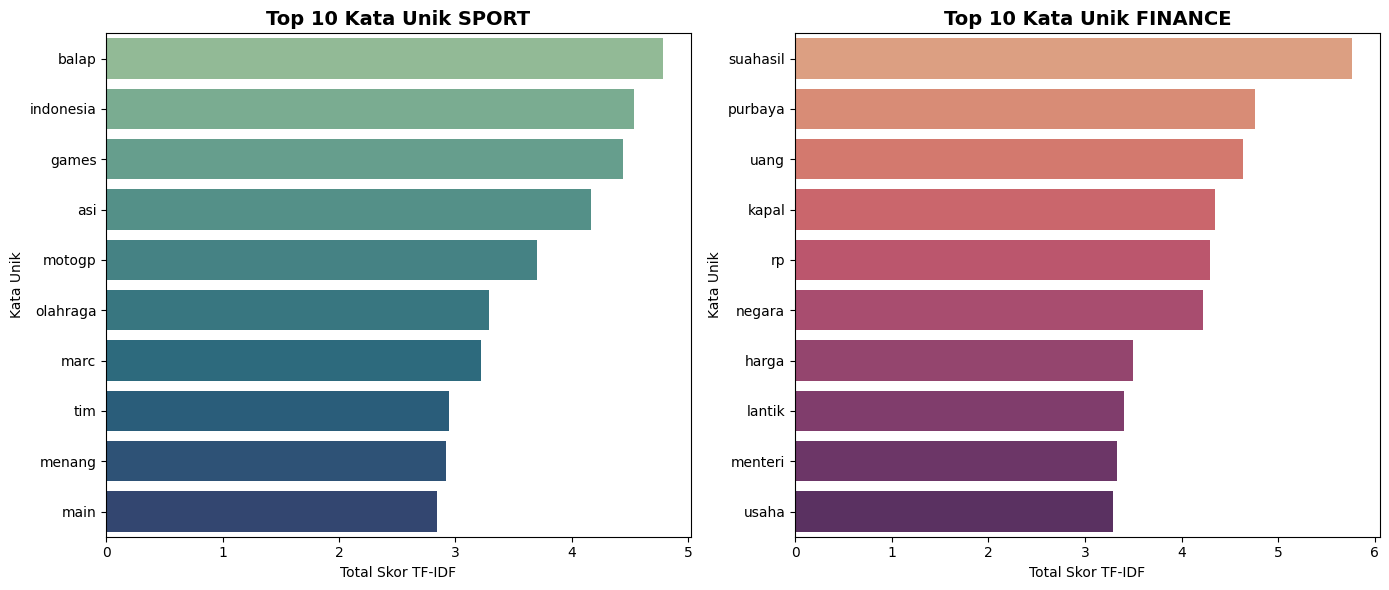

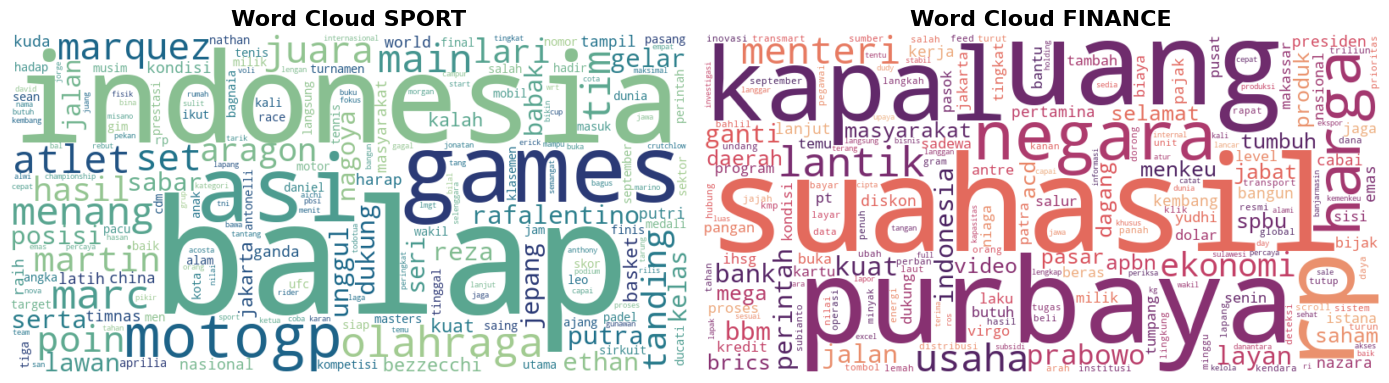

Top 10 SPORT:
balap        4.782590
indonesia    4.532737
games        4.438811
asi          4.161475
motogp       3.704982
olahraga     3.288334
marc         3.219793
tim          2.947061
menang       2.916810
main         2.844205
dtype: float64

Top 10 FINANCE:
suahasil    5.761545
purbaya     4.759459
uang        4.640904
kapal       4.341660
rp          4.294071
negara      4.220206
harga       3.502788
lantik      3.402768
menteri     3.334991
usaha       3.288299
dtype: float64


In [3]:
import warnings

warnings.filterwarnings('ignore', category=ResourceWarning)
warnings.filterwarnings('ignore', message='.*unclosed file.*wordcloud.*stopwords.*')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# Siapkan data setiap kelas secara terpisah
sport_df = df[df['Kategori'] == 'SPORT'].copy()
finance_df = df[df['Kategori'] == 'FINANCE'].copy()

# 1. Inisialisasi dan Transformasi TF-IDF untuk masing-masing kelas
vectorizer_sport = TfidfVectorizer()
vectorizer_finance = TfidfVectorizer()

sport_matrix = vectorizer_sport.fit_transform(sport_df['Teks Bersih'])
finance_matrix = vectorizer_finance.fit_transform(finance_df['Teks Bersih'])

sport_fitur = vectorizer_sport.get_feature_names_out()
finance_fitur = vectorizer_finance.get_feature_names_out()

sport_df_tfidf = pd.DataFrame(sport_matrix.toarray(), columns=sport_fitur)
finance_df_tfidf = pd.DataFrame(finance_matrix.toarray(), columns=finance_fitur)

# Hitung total bobot TF-IDF per kata untuk tiap kelas
sport_skor = sport_df_tfidf.sum().sort_values(ascending=False)
finance_skor = finance_df_tfidf.sum().sort_values(ascending=False)

# VISUALISASI 1: Bar Chart (Top 10 Kata per Kelas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(ax=axes[0], x=sport_skor.head(10).values, y=sport_skor.head(10).index, palette='crest')
axes[0].set_title('Top 10 Kata Unik SPORT', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Skor TF-IDF')
axes[0].set_ylabel('Kata Unik')

sns.barplot(ax=axes[1], x=finance_skor.head(10).values, y=finance_skor.head(10).index, palette='flare')
axes[1].set_title('Top 10 Kata Unik FINANCE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Skor TF-IDF')
axes[1].set_ylabel('Kata Unik')

plt.tight_layout()
plt.show()

# VISUALISASI 2: Word Cloud per Kelas
wordcloud_sport = WordCloud(width=800, height=400, background_color='white', colormap='crest').generate_from_frequencies(dict(zip(sport_skor.index, sport_skor.values)))
wordcloud_finance = WordCloud(width=800, height=400, background_color='white', colormap='flare').generate_from_frequencies(dict(zip(finance_skor.index, finance_skor.values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(wordcloud_sport, interpolation='bilinear')
axes[0].set_title('Word Cloud SPORT', fontsize=16, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wordcloud_finance, interpolation='bilinear')
axes[1].set_title('Word Cloud FINANCE', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('Top 10 SPORT:')
print(sport_skor.head(10))
print('\nTop 10 FINANCE:')
print(finance_skor.head(10))

## Reduksi Dimensi: Principal Component Analysis (PCA)

Hasil dari proses TF-IDF dapat menghasilkan jumlah fitur yang sangat banyak karena setiap kata unik menjadi sebuah kolom. Jumlah fitur yang terlalu besar dapat membuat proses pengolahan data menjadi lebih berat dan meningkatkan risiko terjadinya *Curse of Dimensionality*.

Untuk mengurangi jumlah fitur tersebut, digunakan **Principal Component Analysis (PCA)**. PCA bekerja dengan mengubah sejumlah besar fitur menjadi beberapa komponen utama yang memiliki informasi paling penting dari data.

Melalui proses ini, data TF-IDF yang memiliki dimensi tinggi dapat direpresentasikan dalam dimensi yang lebih rendah. Hasil reduksi tersebut kemudian dapat digunakan untuk mempermudah analisis dan visualisasi data tanpa harus mempertahankan seluruh fitur awal.

In [4]:
from sklearn.decomposition import PCA

# Memisahkan target label dari fitur numerik
X_tfidf = df_tfidf.drop('Kategori', axis=1)

# Mereduksi matriks menjadi 50 komponen utama
n_komponen = 50
pca = PCA(n_components=n_komponen)
pca_matrix = pca.fit_transform(X_tfidf)

# Format ulang ke DataFrame
kolom_pca = [f'PC{i+1}' for i in range(n_komponen)]
df_pca = pd.DataFrame(pca_matrix, columns=kolom_pca)
df_pca.insert(0, 'Kategori', df['Kategori'])

# Ekspor
df_pca.to_csv('pca_berita.csv', index=False)
print(f"Bentuk Matriks PCA: {df_pca.shape[0]} baris x {df_pca.shape[1]} komponen utama.")
display(df_pca.head())

Bentuk Matriks PCA: 195 baris x 51 komponen utama.


,Kategori,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,SPORT,-0.113532,-0.234134,-0.291206,-0.124251,-0.235616,0.065730,-0.172469,-0.105752,0.072010,...,-0.011005,0.185910,-0.096073,-0.009243,-0.034052,-0.011874,0.057813,-0.030097,-0.048572,0.038709
1,SPORT,-0.160882,-0.163456,-0.341221,-0.083606,-0.114945,0.044121,-0.162204,-0.095724,-0.006111,...,0.020915,-0.037719,0.031247,-0.024627,0.044717,0.082614,-0.058756,0.111991,-0.053355,0.044742
2,FINANCE,0.534805,0.069888,-0.056845,-0.066689,0.005062,-0.029492,0.029590,-0.115452,-0.079643,...,0.003808,0.025737,0.006162,0.017056,0.027851,-0.050101,-0.036148,0.108126,-0.001116,-0.028961
3,SPORT,-0.123532,-0.183055,-0.318201,-0.085406,-0.159337,0.053190,-0.120411,-0.006921,-0.084613,...,-0.053849,0.022208,0.008258,0.085121,-0.074554,0.011443,0.021303,-0.123297,-0.024761,0.012009
4,SPORT,-0.062054,-0.169304,-0.275165,-0.076259,-0.182319,0.075452,-0.052280,-0.093321,0.018459,...,-0.050894,0.067397,-0.007043,-0.095654,0.097183,-0.045484,0.043186,0.206436,0.076115,-0.029015


## Analisis Persebaran Data Menggunakan PCA

Setelah proses reduksi dimensi menggunakan PCA dilakukan, dua komponen utama, yaitu **PC1** dan **PC2**, digunakan untuk menampilkan data dalam bentuk grafik dua dimensi. Visualisasi ini bertujuan untuk melihat pola penyebaran berita dari kelas **SPORT** dan **FINANCE**.

Dari grafik tersebut dapat diamati bagaimana posisi data dari kedua kategori tersebar. Apabila data dari masing-masing kelas cenderung berada pada area yang berbeda, berarti terdapat pola atau karakteristik kata yang membedakan kedua kategori tersebut.

Sebaliknya, apabila banyak titik dari kedua kelas berada pada area yang sama, maka terdapat kemiripan karakteristik teks antarberita yang menyebabkan kedua kategori sulit dibedakan hanya berdasarkan fitur yang digunakan.

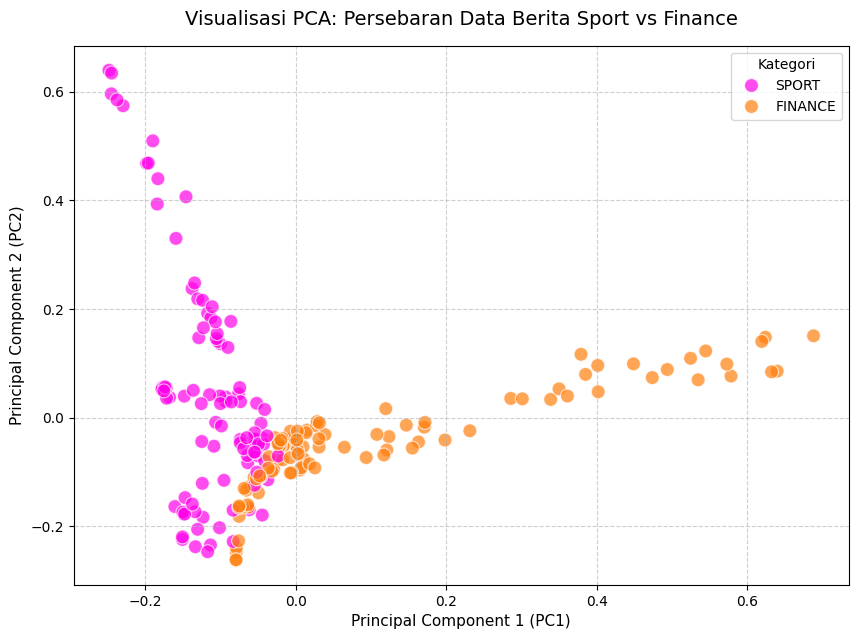

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(10, 7))

# Memplot dua komponen utama pertama (PC1 sebagai sumbu X, PC2 sebagai sumbu Y)
sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='Kategori', 
    palette=["#fe00e9", '#ff7f0e'], # Biru untuk Sport, Oranye untuk Finance
    s=100, # Ukuran titik
    alpha=0.7 # Transparansi agar titik yang bertumpuk terlihat
)

# Menambahkan judul dan label sumbu
plt.title('Visualisasi PCA: Persebaran Data Berita Sport vs Finance', fontsize=14, pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)

# Menambahkan garis bantu (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Merender dan menampilkan grafik ke layar
plt.show()